In [1]:
# Experiment 4 - Car Price Prediction MLOps
# Student: Bhavani Prasad
# GitHub: bhavaniprasad
# Email: bmudili918@gmail.com

from pathlib import Path
import os
import shutil

# Keep the notebook and car_prediction_data.csv in the same working folder.
project_path = Path.cwd()
dataset_name = "car_prediction_data.csv"

print("Project folder:", project_path)
print("Dataset path:", project_path / dataset_name)


Project folder: C:\Users\M Bhavani prasad\carprice-prediction
Dataset path: C:\Users\M Bhavani prasad\carprice-prediction\car_prediction_data.csv


In [2]:
%pwd

'C:\\Users\\M Bhavani prasad\\carprice-prediction'

In [3]:
!cd

C:\Users\M Bhavani prasad\carprice-prediction


In [4]:
# Verify that the dataset is available before starting.
from pathlib import Path

dataset_path = Path("car_prediction_data.csv")

if not dataset_path.exists():
    raise FileNotFoundError(
        "car_prediction_data.csv was not found in the current Jupyter folder. "
        "Place the CSV beside this notebook and run again."
    )

print("Dataset found:", dataset_path.resolve())


Dataset found: C:\Users\M Bhavani prasad\carprice-prediction\car_prediction_data.csv


In [5]:
!dir

 Volume in drive C is OS
 Volume Serial Number is 3454-2DBB

 Directory of C:\Users\M Bhavani prasad\carprice-prediction

09-10-2026  11:20 AM    <DIR>          .
09-10-2026  12:26 AM    <DIR>          ..
09-10-2026  11:20 AM    <DIR>          .ipynb_checkpoints
12-09-2026  03:39 PM            17,209 car_prediction_data.csv
15-09-2026  06:28 AM            35,227 Experiment4_Car_Price_Prediction_MLOps.ipynb
               2 File(s)         52,436 bytes
               3 Dir(s)  21,442,674,688 bytes free


In [6]:
# Initialize Git
!git init
!git status


Reinitialized existing Git repository in C:/Users/M Bhavani prasad/carprice-prediction/.git/
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/

nothing added to commit but untracked files present (use "git add" to track)


In [7]:
# Configure Git identity
!git config user.name "bhavaniprasad"
!git config user.email "bmudili918@gmail.com"
!git branch -M main
!git status


On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/

nothing added to commit but untracked files present (use "git add" to track)


In [8]:
# Connect this local repository to your GitHub repository
!git remote add origin https://github.com/bhavaniprasadmudili/carprice-prediction.git
!git remote -v


error: remote origin already exists.


origin	https://github.com/bhavaniprasadmudili/carprice-prediction.git (fetch)
origin	https://github.com/bhavaniprasadmudili/carprice-prediction.git (push)


In [9]:
# Initialize DVC
!dvc init
!dvc --version
!dir


'dvc' is not recognized as an internal or external command,
operable program or batch file.
'dvc' is not recognized as an internal or external command,
operable program or batch file.


 Volume in drive C is OS
 Volume Serial Number is 3454-2DBB

 Directory of C:\Users\M Bhavani prasad\carprice-prediction

09-10-2026  11:20 AM    <DIR>          .
09-10-2026  12:26 AM    <DIR>          ..
09-10-2026  11:20 AM    <DIR>          .ipynb_checkpoints
12-09-2026  03:39 PM            17,209 car_prediction_data.csv
15-09-2026  06:28 AM            35,227 Experiment4_Car_Price_Prediction_MLOps.ipynb
               2 File(s)         52,436 bytes
               3 Dir(s)  21,442,670,592 bytes free


In [10]:
# Track the dataset with DVC
!dvc add "car_prediction_data.csv"
!dir


'dvc' is not recognized as an internal or external command,
operable program or batch file.


 Volume in drive C is OS
 Volume Serial Number is 3454-2DBB

 Directory of C:\Users\M Bhavani prasad\carprice-prediction

09-10-2026  11:20 AM    <DIR>          .
09-10-2026  12:26 AM    <DIR>          ..
09-10-2026  11:20 AM    <DIR>          .ipynb_checkpoints
12-09-2026  03:39 PM            17,209 car_prediction_data.csv
15-09-2026  06:28 AM            35,227 Experiment4_Car_Price_Prediction_MLOps.ipynb
               2 File(s)         52,436 bytes
               3 Dir(s)  21,442,670,592 bytes free


In [11]:
# Commit DVC metadata to Git
!git add "car_prediction_data.csv.dvc"
!git add .dvc/config .dvcignore
!git status
!git commit -m "Initialize Experiment 4 with DVC dataset tracking"


fatal: pathspec 'car_prediction_data.csv.dvc' did not match any files
fatal: pathspec '.dvc/config' did not match any files


On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/

nothing added to commit but untracked files present (use "git add" to track)
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/

nothing added to commit but untracked files present (use "git add" to track)


In [12]:
# Push initial repository state to GitHub
!git push -u origin main


branch 'main' set up to track 'origin/main'.


Everything up-to-date


## STAGE 1 — DATA INGESTION

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [14]:
data = pd.read_csv("car_prediction_data.csv")


In [15]:
print("Dataset Shape:", data.shape)


Dataset Shape: (301, 9)


In [16]:
data.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [17]:
print(data.columns.tolist())


['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


In [18]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


## STAGE 2 — DATA PROFILING

In [19]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [20]:
data.describe()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [21]:
data.describe(include="all")


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


In [22]:
print(data.dtypes)


Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object


In [23]:
print(data.isnull().sum())


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [24]:
missing_percentage = (data.isnull().sum() / len(data)) * 100
print(missing_percentage)


Car_Name         0.0
Year             0.0
Selling_Price    0.0
Present_Price    0.0
Kms_Driven       0.0
Fuel_Type        0.0
Seller_Type      0.0
Transmission     0.0
Owner            0.0
dtype: float64


In [25]:
print("Duplicate Rows:", data.duplicated().sum())


Duplicate Rows: 2


In [26]:
for column in data.columns:
    print(column, ":", data[column].nunique())


Car_Name : 98
Year : 16
Selling_Price : 156
Present_Price : 147
Kms_Driven : 206
Fuel_Type : 3
Seller_Type : 2
Transmission : 2
Owner : 3


In [27]:
print("Number of Rows:", data.shape[0])
print("Number of Columns:", data.shape[1])


Number of Rows: 301
Number of Columns: 9


## NEXT → STAGE 3: DATA VALIDATION

In [28]:
print("Dataset Shape:", data.shape)


Dataset Shape: (301, 9)


In [29]:
missing_values = data.isnull().sum()
print("Missing Values:")
print(missing_values)


Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [30]:
duplicate_rows = data.duplicated().sum()
print("Duplicate Rows:", duplicate_rows)


Duplicate Rows: 2


In [31]:
print(data.dtypes)


Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object


In [32]:
numerical_columns = data.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = data.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Columns:", numerical_columns)
print("Categorical Columns:", categorical_columns)


Numerical Columns: ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']
Categorical Columns: ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']


C:\Users\M Bhavani prasad\AppData\Local\Temp\ipykernel_3232\2827738643.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(


In [33]:
for column in data.columns:
    print(column, "Unique Values:", data[column].nunique())


Car_Name Unique Values: 98
Year Unique Values: 16
Selling_Price Unique Values: 156
Present_Price Unique Values: 147
Kms_Driven Unique Values: 206
Fuel_Type Unique Values: 3
Seller_Type Unique Values: 2
Transmission Unique Values: 2
Owner Unique Values: 3


In [34]:
print("Total Rows:", data.shape[0])
print("Total Columns:", data.shape[1])
print("Total Missing Values:", data.isnull().sum().sum())
print("Total Duplicate Rows:", data.duplicated().sum())


Total Rows: 301
Total Columns: 9
Total Missing Values: 0
Total Duplicate Rows: 2


## STAGE 4 — DATA CLEANING

In [35]:
cleaned_data = data.copy()


In [36]:
cleaned_data = cleaned_data.drop_duplicates()

print("Dataset Shape:", cleaned_data.shape)


Dataset Shape: (299, 9)


In [37]:
numerical_columns = cleaned_data.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = cleaned_data.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Columns:", numerical_columns)
print("Categorical Columns:", categorical_columns)


Numerical Columns: ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']
Categorical Columns: ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']


C:\Users\M Bhavani prasad\AppData\Local\Temp\ipykernel_3232\2143272090.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = cleaned_data.select_dtypes(


In [38]:
for column in numerical_columns:
    cleaned_data[column] = cleaned_data[column].fillna(
        cleaned_data[column].median()
    )


In [39]:
for column in categorical_columns:
    if cleaned_data[column].isnull().sum() > 0:
        cleaned_data[column] = cleaned_data[column].fillna(
            cleaned_data[column].mode()[0]
        )


In [40]:
print("Missing Values:")
print(cleaned_data.isnull().sum())

print("Duplicate Rows:", cleaned_data.duplicated().sum())

print("Final Dataset Shape:", cleaned_data.shape)


Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
Duplicate Rows: 0
Final Dataset Shape: (299, 9)


## NEXT → STAGE 5: DATA TRANSFORMATION

In [41]:
transformed_data = cleaned_data.copy()


In [42]:
categorical_columns = transformed_data.select_dtypes(
    include=["object"]
).columns.tolist()

print(categorical_columns)


['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission']


C:\Users\M Bhavani prasad\AppData\Local\Temp\ipykernel_3232\4212655268.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = transformed_data.select_dtypes(


In [43]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    transformed_data[column] = encoder.fit_transform(
        transformed_data[column].astype(str)
    )
    label_encoders[column] = encoder


In [44]:
transformed_data.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,90,2014,3.35,5.59,27000,2,0,1,0
1,93,2013,4.75,9.54,43000,1,0,1,0
2,68,2017,7.25,9.85,6900,2,0,1,0
3,96,2011,2.85,4.15,5200,2,0,1,0
4,92,2014,4.60,6.87,42450,1,0,1,0


In [45]:
print(transformed_data.dtypes)


Car_Name           int64
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type          int64
Seller_Type        int64
Transmission       int64
Owner              int64
dtype: object


In [46]:
print(transformed_data.isnull().sum())


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [47]:
print("Dataset Shape:", transformed_data.shape)
print("Columns:", transformed_data.columns.tolist())


Dataset Shape: (299, 9)
Columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


## STAGE 6 — FEATURE ENGINEERING

In [48]:
feature_data = transformed_data.copy()


In [49]:
# Create car age from the manufacturing year.
from datetime import datetime

current_year = datetime.now().year

feature_data["Car_Age"] = (
    current_year - feature_data["Year"]
)


In [50]:
# Create a price-per-kilometre feature.
feature_data["Price_per_Km"] = (
    feature_data["Present_Price"] /
    feature_data["Kms_Driven"].replace(0, np.nan)
)

feature_data["Price_per_Km"] = (
    feature_data["Price_per_Km"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(feature_data["Price_per_Km"].median())
)


In [51]:
feature_data.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Price_per_Km
0,90,2014,3.35,5.59,27000,2,0,1,0,12,0.000207
1,93,2013,4.75,9.54,43000,1,0,1,0,13,0.000222
2,68,2017,7.25,9.85,6900,2,0,1,0,9,0.001428
3,96,2011,2.85,4.15,5200,2,0,1,0,15,0.000798
4,92,2014,4.60,6.87,42450,1,0,1,0,12,0.000162


In [52]:
print(feature_data.columns.tolist())


['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age', 'Price_per_Km']


In [53]:
print("Feature Data Shape:", feature_data.shape)


Feature Data Shape: (299, 11)


## STAGE 7 — PREPARE FEATURES (X) AND TARGET (y)

In [54]:
X = feature_data.drop("Selling_Price", axis=1)

y = feature_data["Selling_Price"]


In [55]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (299, 10)
Target Shape: (299,)


In [56]:
X.head()


,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Price_per_Km
0,90,2014,5.59,27000,2,0,1,0,12,0.000207
1,93,2013,9.54,43000,1,0,1,0,13,0.000222
2,68,2017,9.85,6900,2,0,1,0,9,0.001428
3,96,2011,4.15,5200,2,0,1,0,15,0.000798
4,92,2014,6.87,42450,1,0,1,0,12,0.000162


In [57]:
y.head()


0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [58]:
print(X.columns.tolist())


['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age', 'Price_per_Km']


## STAGE 8: TRAIN-TEST SPLIT

In [59]:
from sklearn.model_selection import train_test_split


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [61]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (239, 10)
X_test: (60, 10)
y_train: (239,)
y_test: (60,)


In [62]:
X_train.head()


,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Price_per_Km
6,68,2015,8.12,18796,2,0,1,0,11,0.000432
185,50,2008,0.58,1900,2,1,0,0,18,0.000305
187,36,2013,0.51,32000,2,1,1,0,13,0.000016
148,15,2010,0.94,45000,2,1,1,0,16,0.000021
31,90,2011,4.89,54200,2,0,1,0,15,0.000090


In [63]:
X_test.head()


,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Price_per_Km
283,69,2016,11.80,9010,2,0,1,0,10,0.001310
267,69,2016,9.40,19434,1,0,1,0,10,0.000484
166,25,2016,0.55,1000,2,1,1,0,10,0.000550
9,68,2015,8.92,42367,1,0,1,0,11,0.000211
78,71,2010,22.83,80000,2,0,0,0,16,0.000285


## STAGE 9 — DATA PREPROCESSING / FEATURE SCALING

In [64]:
from sklearn.preprocessing import StandardScaler


In [65]:
scaler = StandardScaler()


In [66]:
X_train_scaled = scaler.fit_transform(X_train)


In [67]:
X_test_scaled = scaler.transform(X_test)


In [68]:
print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)


Scaled Training Shape: (239, 10)
Scaled Testing Shape: (60, 10)


In [69]:
print(X_train_scaled[:5])


[[ 0.22643242  0.46310243  0.0792308  -0.55609426  0.48215907 -0.73616267
   0.386055   -0.17370208 -0.46310243  0.19640994]
 [-0.4663928  -1.97328237 -0.77591555 -1.1560003   0.48215907  1.35839541
  -2.5903045  -0.17370208  1.97328237 -0.08460394]
 [-1.00525686 -0.23300751 -0.78385457 -0.08727564  0.48215907  1.35839541
   0.386055   -0.17370208  0.23300751 -0.72609188]
 [-1.81355295 -1.27717243 -0.73508628  0.37429979  0.48215907  1.35839541
   0.386055   -0.17370208  1.27717243 -0.71511375]
 [ 1.0732188  -0.92911746 -0.28709847  0.70095318  0.48215907 -0.73616267
   0.386055   -0.17370208  0.92911746 -0.56139087]]


## STAGE 10: MODEL TRAINING

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor


In [71]:
linear_model = LinearRegression()

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)


In [72]:
linear_model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.15, 0.44, 3.59,..., 0.09,-0.44, 0.69]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.584
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[26. ,25.73,16.09,..., 8.44, 6.23, 0. ]"


In [73]:
random_forest_model.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [74]:
gradient_boosting_model.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [75]:
linear_predictions = linear_model.predict(X_test_scaled)

random_forest_predictions = random_forest_model.predict(X_test_scaled)

gradient_boosting_predictions = gradient_boosting_model.predict(
    X_test_scaled
)


## STAGE 11: MODEL EVALUATION AND COMPARISON

In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd


In [77]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = mean_squared_error(y_test, linear_predictions) ** 0.5
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)


Linear Regression
MAE: 1.3661558254319073
RMSE: 2.217363869190308
R2 Score: 0.8092324329765546


In [78]:
rf_mae = mean_absolute_error(y_test, random_forest_predictions)
rf_rmse = mean_squared_error(y_test, random_forest_predictions) ** 0.5
rf_r2 = r2_score(y_test, random_forest_predictions)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)


Random Forest
MAE: 1.3160433333333335
RMSE: 3.251805830970436
R2 Score: 0.5897204990520755


In [79]:
gb_mae = mean_absolute_error(y_test, gradient_boosting_predictions)
gb_rmse = mean_squared_error(y_test, gradient_boosting_predictions) ** 0.5
gb_r2 = r2_score(y_test, gradient_boosting_predictions)

print("Gradient Boosting")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2 Score:", gb_r2)


Gradient Boosting
MAE: 1.1997304574628211
RMSE: 2.6701731545585607
R2 Score: 0.7233635147211694


In [80]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.366156,2.217364,0.809232
1,Random Forest,1.316043,3.251806,0.589720
2,Gradient Boosting,1.199730,2.670173,0.723364


In [81]:
results.sort_values(by="R2 Score", ascending=False)


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.366156,2.217364,0.809232
2,Gradient Boosting,1.199730,2.670173,0.723364
1,Random Forest,1.316043,3.251806,0.589720


## STAGE 12: BEST MODEL SELECTION

In [82]:
best_model_name = results.loc[
    results["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)


Best Model: Linear Regression


In [83]:
best_model_results = results.loc[
    results["R2 Score"].idxmax()
]

print(best_model_results)


Model       Linear Regression
MAE                  1.366156
RMSE                 2.217364
R2 Score             0.809232
Name: 0, dtype: object


In [84]:
if best_model_name == "Linear Regression":
    best_model = linear_model
    best_predictions = linear_predictions
elif best_model_name == "Random Forest":
    best_model = random_forest_model
    best_predictions = random_forest_predictions
else:
    best_model = gradient_boosting_model
    best_predictions = gradient_boosting_predictions


In [85]:
best_mae = best_model_results["MAE"]
best_rmse = best_model_results["RMSE"]
best_r2 = best_model_results["R2 Score"]

print("Best Model:", best_model_name)
print("Best MAE:", best_mae)
print("Best RMSE:", best_rmse)
print("Best R2 Score:", best_r2)


Best Model: Linear Regression
Best MAE: 1.3661558254319073
Best RMSE: 2.217363869190308
Best R2 Score: 0.8092324329765546


## STAGE 13 — MLFLOW EXPERIMENT TRACKING

In [86]:
!pip install mlflow


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
import mlflow
import mlflow.sklearn

# Use a SQLite backend so local Model Registry works reliably.
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Car_Price_Prediction_Experiment")


2026/10/09 11:22:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/09 11:22:17 INFO mlflow.store.db.utils: Updating database tables
2026/10/09 11:22:20 INFO mlflow.tracking.fluent: Experiment with name 'Car_Price_Prediction_Experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:C:/Users/M Bhavani prasad/carprice-prediction/mlruns/1', creation_time=1791525140452, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791525140452, lifecycle_stage='active', name='Car_Price_Prediction_Experiment', tags={}, trace_location=None, workspace='default'>

In [88]:
with mlflow.start_run(run_name=f"{best_model_name}_car_price"):

    mlflow.log_param("model_name", best_model_name)
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)

    if best_model_name == "Random Forest":
        mlflow.log_param("n_estimators", 100)

    mlflow.log_metric("MAE", float(best_mae))
    mlflow.log_metric("RMSE", float(best_rmse))
    mlflow.log_metric("R2_Score", float(best_r2))

print("Experiment tracked successfully!")


Experiment tracked successfully!


In [89]:
# Log the selected best model in a separate MLflow run.
with mlflow.start_run(run_name=f"{best_model_name}_model") as run:

    mlflow.log_param("model_name", best_model_name)
    mlflow.log_metric("MAE", float(best_mae))
    mlflow.log_metric("RMSE", float(best_rmse))
    mlflow.log_metric("R2_Score", float(best_r2))

    mlflow.sklearn.log_model(
        sk_model=best_model,
        artifact_path="car_price_model"
    )

    model_run_id = run.info.run_id

print("Model and metrics tracked successfully!")
print("Model Run ID:", model_run_id)


2026/10/09 11:22:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model and metrics tracked successfully!
Model Run ID: 9949d14edf4e4bc6bfb93f991df982dd


In [90]:
runs = mlflow.search_runs(
    experiment_names=["Car_Price_Prediction_Experiment"]
)

runs[["run_id", "status", "artifact_uri"]]


,run_id,status,artifact_uri
0,9949d14edf4e4bc6bfb93f991df982dd,FINISHED,file:C:/Users/M Bhavani prasad/carprice-predic...
1,86b32c81b8134d71a61b6f6161ba79ff,FINISHED,file:C:/Users/M Bhavani prasad/carprice-predic...


In [91]:
# Open MLflow UI from a separate Anaconda Prompt / terminal:
# mlflow ui --port 5000 --backend-store-uri sqlite:///mlflow.db

print("Run the command above in a separate terminal, then open http://127.0.0.1:5000")


Run the command above in a separate terminal, then open http://127.0.0.1:5000


## STAGE 14 — MLFLOW MODEL REGISTRY

In [92]:
model_uri = f"runs:/{model_run_id}/car_price_model"

print("Model URI:", model_uri)


Model URI: runs:/9949d14edf4e4bc6bfb93f991df982dd/car_price_model


In [93]:
registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="CarPricePredictionModel"
)

print("Model Name:", registered_model.name)
print("Model Version:", registered_model.version)


Successfully registered model 'CarPricePredictionModel'.
2026/10/09 11:22:40 WARNING mlflow.tracking._model_registry.fluent: Run with id 9949d14edf4e4bc6bfb93f991df982dd has no artifacts at artifact path 'car_price_model', registering model based on models:/m-d70472432eca4e499f597a4da696d536 instead


Model Name: CarPricePredictionModel
Model Version: 1


Created version '1' of model 'CarPricePredictionModel'.


## STAGE 15 — MODEL COMPARISON

In [94]:
print(results)

comparison_results = results.sort_values(
    by="R2 Score",
    ascending=False
)

comparison_results


               Model       MAE      RMSE  R2 Score
0  Linear Regression  1.366156  2.217364  0.809232
1      Random Forest  1.316043  3.251806  0.589720
2  Gradient Boosting  1.199730  2.670173  0.723364


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.366156,2.217364,0.809232
2,Gradient Boosting,1.199730,2.670173,0.723364
1,Random Forest,1.316043,3.251806,0.589720


In [95]:
print("Best Model:", best_model_name)
print("Best MAE:", best_mae)
print("Best RMSE:", best_rmse)
print("Best R2 Score:", best_r2)


Best Model: Linear Regression
Best MAE: 1.3661558254319073
Best RMSE: 2.217363869190308
Best R2 Score: 0.8092324329765546


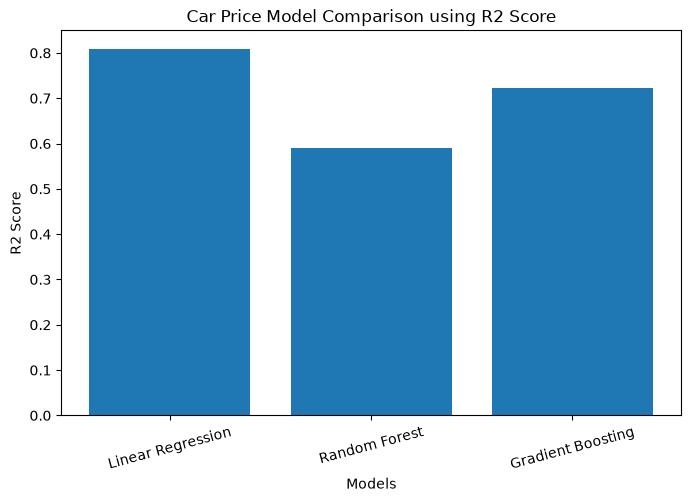

In [96]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Car Price Model Comparison using R2 Score")

plt.xticks(rotation=15)

plt.show()


## STAGE 16 — DEPLOYMENT / CAR PRICE PREDICTION

In [97]:
print(X.columns.tolist())


['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age', 'Price_per_Km']


In [98]:
# Example input based on a real category/value present in the supplied dataset.
new_car = pd.DataFrame({
    "Car_Name": ["ritz"],
    "Year": [2014],
    "Present_Price": [5.59],
    "Kms_Driven": [27000],
    "Fuel_Type": ["Petrol"],
    "Seller_Type": ["Dealer"],
    "Transmission": ["Manual"],
    "Owner": [0]
})

new_car


,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,5.59,27000,Petrol,Dealer,Manual,0


In [99]:
# Apply the same label encoders used during training.
for column in categorical_columns:
    new_car[column] = label_encoders[column].transform(
        new_car[column].astype(str)
    )


In [100]:
# Apply the same feature engineering used for the training data.
new_car["Car_Age"] = (
    current_year - new_car["Year"]
)

new_car["Price_per_Km"] = (
    new_car["Present_Price"] /
    new_car["Kms_Driven"].replace(0, np.nan)
)

new_car["Price_per_Km"] = (
    new_car["Price_per_Km"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(feature_data["Price_per_Km"].median())
)


In [101]:
new_car = new_car[X.columns]

print(new_car.columns.tolist())


['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age', 'Price_per_Km']


In [102]:
new_car_scaled = scaler.transform(new_car)


In [103]:
predicted_price = best_model.predict(new_car_scaled)

print("Predicted Car Selling Price:", predicted_price[0])


Predicted Car Selling Price: 3.6872976100705035


## STAGE 17 — FINAL GIT COMMIT AND PUSH

In [104]:
!git status


On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	mlflow.db
	mlruns/
	sales_mlflow_prefect_pipeline.ipynb

nothing added to commit but untracked files present (use "git add" to track)


In [105]:
!dir *.ipynb


 Volume in drive C is OS
 Volume Serial Number is 3454-2DBB

 Directory of C:\Users\M Bhavani prasad\carprice-prediction

15-09-2026  06:28 AM            35,227 Experiment4_Car_Price_Prediction_MLOps.ipynb
09-10-2026  11:22 AM            24,022 sales_mlflow_prefect_pipeline.ipynb
               2 File(s)         59,249 bytes
               0 Dir(s)  21,426,196,480 bytes free


In [106]:
!dir


 Volume in drive C is OS
 Volume Serial Number is 3454-2DBB

 Directory of C:\Users\M Bhavani prasad\carprice-prediction

09-10-2026  11:22 AM    <DIR>          .
09-10-2026  12:26 AM    <DIR>          ..
09-10-2026  11:20 AM    <DIR>          .ipynb_checkpoints
12-09-2026  03:39 PM            17,209 car_prediction_data.csv
15-09-2026  06:28 AM            35,227 Experiment4_Car_Price_Prediction_MLOps.ipynb
09-10-2026  11:22 AM           954,368 mlflow.db
09-10-2026  11:22 AM    <DIR>          mlruns
09-10-2026  11:22 AM            24,022 sales_mlflow_prefect_pipeline.ipynb
               4 File(s)      1,030,826 bytes
               4 Dir(s)  21,426,196,480 bytes free


In [107]:
!git add .


In [108]:
!git status


On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   .ipynb_checkpoints/Experiment4_Car_Price_Prediction_MLOps-checkpoint.ipynb
	new file:   mlflow.db
	new file:   mlruns/1/models/m-d70472432eca4e499f597a4da696d536/artifacts/MLmodel
	new file:   mlruns/1/models/m-d70472432eca4e499f597a4da696d536/artifacts/conda.yaml
	new file:   mlruns/1/models/m-d70472432eca4e499f597a4da696d536/artifacts/model.skops
	new file:   mlruns/1/models/m-d70472432eca4e499f597a4da696d536/artifacts/python_env.yaml
	new file:   mlruns/1/models/m-d70472432eca4e499f597a4da696d536/artifacts/requirements.txt
	new file:   sales_mlflow_prefect_pipeline.ipynb



In [109]:
!git commit -m "Complete Car Price Prediction MLOps pipeline"


[main 57f81fe] Complete Car Price Prediction MLOps pipeline
 8 files changed, 2446 insertions(+)
 create mode 100644 .ipynb_checkpoints/Experiment4_Car_Price_Prediction_MLOps-checkpoint.ipynb
 create mode 100644 mlflow.db
 create mode 100644 mlruns/1/models/m-d70472432eca4e499f597a4da696d536/artifacts/MLmodel
 create mode 100644 mlruns/1/models/m-d70472432eca4e499f597a4da696d536/artifacts/conda.yaml
 create mode 100644 mlruns/1/models/m-d70472432eca4e499f597a4da696d536/artifacts/model.skops
 create mode 100644 mlruns/1/models/m-d70472432eca4e499f597a4da696d536/artifacts/python_env.yaml
 create mode 100644 mlruns/1/models/m-d70472432eca4e499f597a4da696d536/artifacts/requirements.txt
 create mode 100644 sales_mlflow_prefect_pipeline.ipynb


In [110]:
!git push origin main


To https://github.com/bhavaniprasadmudili/carprice-prediction.git
   b48e88a..57f81fe  main -> main


## RESULT / OBSERVATION

The Car Price Prediction MLOps pipeline was completed using Git, DVC, MLflow and MLflow Model Registry.

Record the final values produced by your execution:
- Best Model: ______________________
- Best MAE: ______________________
- Best RMSE: ______________________
- Best R2 Score: ______________________
- Predicted Selling Price: ______________________
- MLflow Model Version: ______________________

**Important:** Do not manually enter MLflow run IDs, model versions, metrics or prediction values. Copy them from the outputs generated by the executed notebook.


In [111]:
!pip install fastapi uvicorn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [113]:
!pip install nest_asyncio

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [115]:

import sys

print("Python executable:", sys.executable)

%pip install nest_asyncio


Python executable: D:\mlflow_prefect_pipeline\.venv\Scripts\python.exe
Note: you may need to restart the kernel to use updated packages.


In [116]:

import nest_asyncio
nest_asyncio.apply()

from fastapi import FastAPI
from pydantic import BaseModel
import mlflow
import pandas as pd
import uvicorn

print("All imports successful!")


All imports successful!


In [117]:

import sys
print("Active Python:", sys.executable)

%pip install --upgrade --force-reinstall nest_asyncio


Active Python: D:\mlflow_prefect_pipeline\.venv\Scripts\python.exe
  Using cached nest_asyncio-1.6.0-py3-none-any.whl.metadata (2.8 kB)
Using cached nest_asyncio-1.6.0-py3-none-any.whl (5.2 kB)
  Attempting uninstall: nest_asyncio
    Found existing installation: nest-asyncio 1.6.0
    Uninstalling nest-asyncio-1.6.0:
      Successfully uninstalled nest-asyncio-1.6.0
Note: you may need to restart the kernel to use updated packages.
